In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving VD_HCC.xlsx to VD_HCC.xlsx


In [3]:
train_data_path = "VD_HCC.xlsx"
df_train = pd.read_excel(train_data_path)
df_train.describe()

,record_id,Age,Gender,Platelets,INR,AST,ALT,Total_Bil,Dir_Bil,Albumin,...,Glucose,HBsAg,HCVAb,CEA,AFP,CA19-9,AST/ALT,APRI,FIB-4,label
count,8.800000e+02,880.000000,879.000000,873.000000,839.000000,879.000000,879.000000,832.000000,815.000000,809.000000,...,865.000000,877.000000,878.000000,742.000000,8.790000e+02,851.000000,879.000000,873.000000,873.000000,880.000000
mean,6.351616e+06,55.001136,0.659841,260.754387,1.093814,49.308601,47.013561,22.751454,10.171607,39.473572,...,6.211503,0.231471,0.021640,90.061833,4.674914e+03,270.456604,1.274794,0.634555,2.075561,0.344318
std,8.354255e+06,15.306687,0.474032,106.084665,0.357441,87.931018,98.373096,52.118226,31.693634,5.471421,...,2.496184,0.422013,0.145588,1728.708733,5.653894e+04,3870.933276,0.647147,1.312126,3.792164,0.475416
min,4.000000e+00,7.000000,0.000000,20.000000,0.820000,3.500000,3.700000,3.000000,0.300000,16.700000,...,2.470000,0.000000,0.000000,0.200000,6.000000e-01,0.090000,0.097200,0.038000,0.084200,0.000000
25%,2.020106e+06,45.000000,0.000000,188.900000,1.000000,21.100000,16.095000,8.600000,1.900000,36.600000,...,5.030000,0.000000,0.000000,1.592500,1.690000e+00,7.730000,0.900000,0.187400,0.809900,0.000000
50%,2.020602e+06,58.000000,1.000000,250.000000,1.050000,29.000000,26.470000,11.200000,2.900000,40.200000,...,5.450000,0.000000,0.000000,2.525000,2.950000e+00,15.340000,1.170000,0.310000,1.348900,0.000000
75%,2.020102e+07,65.250000,1.000000,315.000000,1.120000,46.970000,46.495000,15.700000,5.600000,42.800000,...,6.440000,0.000000,0.000000,4.350000,6.395000e+00,32.695000,1.500000,0.576400,2.221300,1.000000
max,2.020147e+07,93.000000,1.000000,787.000000,9.650000,1286.970000,2097.000000,572.300000,403.400000,79.400000,...,27.020000,1.000000,1.000000,46170.000000,1.210000e+06,109660.000000,7.310000,21.104400,82.234700,1.000000


In [4]:
df_train.columns

Index(['record_id', 'Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT',
       'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose',
       'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4',
       'label'],
      dtype='object')

In [6]:
selected_columns = ['Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT',
       'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose',
       'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4', 'label']

data_train = df_train.copy()

X_train = data_train[selected_columns].drop(columns=['label'])
y_train = data_train.label

# 1. Information gain

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

# Convert back to DataFrame to retain column names
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=X_train.columns)

mi_scores = mutual_info_classif(X_train_imputed_df, y_train, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Information_Gain': mi_scores
}).sort_values(by='Information_Gain', ascending=False)

print(mi_df)

top_k = 14
top_features = mi_df.head(top_k)['Feature'].tolist()
print("Top", top_k, "features by IG:", top_features)


       Feature  Information_Gain
15         AFP          0.239916
12       HBsAg          0.200906
18        APRI          0.191842
4          AST          0.148259
14         CEA          0.141510
19       FIB-4          0.133814
5          ALT          0.131608
2    Platelets          0.105947
6    Total_Bil          0.071936
3          INR          0.057247
16      CA19-9          0.046367
0          Age          0.035400
10  Creatinine          0.018841
7      Dir_Bil          0.015167
13       HCVAb          0.011969
9          Ure          0.011776
1       Gender          0.003516
8      Albumin          0.001361
11     Glucose          0.000000
17     AST/ALT          0.000000
Top 14 features by IG: ['AFP', 'HBsAg', 'APRI', 'AST', 'CEA', 'FIB-4', 'ALT', 'Platelets', 'Total_Bil', 'INR', 'CA19-9', 'Age', 'Creatinine', 'Dir_Bil']


# 2. Weight by Correlation

In [ ]:
corr_scores = {}
for col in X_train.columns:
    corr = X_train[col].corr(y_train)
    corr_scores[col] = abs(corr)

corr_df = pd.DataFrame({
    'Feature': list(corr_scores.keys()),
    'Correlation_with_Label': list(corr_scores.values())
}).sort_values(by='Correlation_with_Label', ascending=False)

print(corr_df)

top_k = 10
top_features_corr = corr_df.head(top_k)['Feature'].tolist()
print("Top", top_k, "features by correlation Corr:", top_features_corr)


       Feature  Correlation_with_Label
12       HBsAg                0.630284
2    Platelets                0.338452
19       FIB-4                0.251074
1       Gender                0.212550
18        APRI                0.203898
13       HCVAb                0.188412
4          AST                0.120892
15         AFP                0.113633
0          Age                0.100001
8      Albumin                0.062618
5          ALT                0.060337
7      Dir_Bil                0.054621
10  Creatinine                0.053597
6    Total_Bil                0.052101
16      CA19-9                0.041110
14         CEA                0.027734
17     AST/ALT                0.026880
3          INR                0.022473
9          Ure                0.014844
11     Glucose                0.005661
Top 10 features by correlation Corr: ['HBsAg', 'Platelets', 'FIB-4', 'Gender', 'APRI', 'HCVAb', 'AST', 'AFP', 'Age', 'Albumin']


# 3. Recursive Feature Elimination

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=10, step=1)
rfe.fit(X_train, y_train)

# Lấy danh sách đặc trưng đã chọn
selected_features = X_train.columns[rfe.support_].tolist()

# Bảng ranking
ranking = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking')

print("Top features selected by RFE with Random Forest:", selected_features)
print(ranking)



Top features selected by RFE with Random Forest: ['Platelets', 'AST', 'ALT', 'Total_Bil', 'HBsAg', 'CEA', 'AFP', 'CA19-9', 'APRI', 'FIB-4']
       Feature  Selected  Ranking
2    Platelets      True        1
6    Total_Bil      True        1
5          ALT      True        1
4          AST      True        1
15         AFP      True        1
12       HBsAg      True        1
14         CEA      True        1
16      CA19-9      True        1
18        APRI      True        1
19       FIB-4      True        1
3          INR     False        2
7      Dir_Bil     False        3
8      Albumin     False        4
0          Age     False        5
10  Creatinine     False        6
11     Glucose     False        7
17     AST/ALT     False        8
9          Ure     False        9
1       Gender     False       10
13       HCVAb     False       11


# 4. RandomForest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Tính importance trực tiếp từ Random Forest
feat_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'RF_importance': rf.feature_importances_
}).sort_values(by='RF_importance', ascending=False)

print("Feature importance trực tiếp từ Random Forest:")
print(feat_importances)


Feature importance trực tiếp từ Random Forest:
       Feature  RF_importance
15         AFP       0.203851
12       HBsAg       0.161624
14         CEA       0.110725
18        APRI       0.088032
4          AST       0.061070
5          ALT       0.051887
2    Platelets       0.049986
19       FIB-4       0.045330
3          INR       0.030478
6    Total_Bil       0.029367
16      CA19-9       0.028324
7      Dir_Bil       0.024700
10  Creatinine       0.017921
0          Age       0.017832
9          Ure       0.017715
17     AST/ALT       0.017536
8      Albumin       0.017311
11     Glucose       0.016459
1       Gender       0.005630
13       HCVAb       0.004222


# 5. Neighborhood Component Analysis

In [ ]:
nca = NeighborhoodComponentsAnalysis(random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('nca', nca)
])

# Use the imputed data X_train_imputed_df to fit the pipeline
pipe.fit(X_train_imputed_df, y_train)

import numpy as np

nca_weights = np.linalg.norm(pipe.named_steps['nca'].components_, axis=0)

nca_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'NCA_importance': nca_weights
}).sort_values(by='NCA_importance', ascending=False)

print(nca_importance)

top_k = 10
top_features_nca = nca_importance.head(top_k)['Feature'].tolist()
print("Top", top_k, "features by NCA:", top_features_nca)

       Feature  NCA_importance
12       HBsAg       27.403362
2    Platelets       24.249237
3          INR       21.452358
4          AST       16.435688
5          ALT       16.333402
0          Age       15.657454
18        APRI       15.499272
9          Ure       15.133055
17     AST/ALT       14.263310
19       FIB-4       14.057429
8      Albumin       11.118890
11     Glucose        9.874391
7      Dir_Bil        8.719277
15         AFP        8.646021
1       Gender        7.715622
6    Total_Bil        7.481661
10  Creatinine        6.164911
13       HCVAb        4.369237
16      CA19-9        2.790391
14         CEA        1.726048
Top 10 features by NCA: ['HBsAg', 'Platelets', 'INR', 'AST', 'ALT', 'Age', 'APRI', 'Ure', 'AST/ALT', 'FIB-4']


#6. Lasso Regression

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Khởi tạo dải giá trị C
Cs = np.logspace(-4, 0, 50)

# Huấn luyện Lasso (L1)
lasso_cv = LogisticRegressionCV(
    Cs=Cs,
    penalty='l1',
    solver='saga',
    cv=20,
    max_iter=10000,
    random_state=42,
    scoring='roc_auc',
    class_weight='balanced'
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed_df)
lasso_cv.fit(X_train_scaled, y_train)

# Lấy hệ số và ánh xạ với tên cột
coef_cv = lasso_cv.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X_train_imputed_df.columns,
    'Coefficient': coef_cv,
    'Abs_Coefficient': np.abs(coef_cv)
})

# Sắp xếp theo giá trị tuyệt đối giảm dần và lấy top 12
top_12_lasso = feature_importance.sort_values(by='Abs_Coefficient', ascending=False).head(12)

print("Best C:", lasso_cv.C_[0])
print("\nTop 12 features selected by Lasso (descending order of importance):")
print(top_12_lasso[['Feature', 'Coefficient', 'Abs_Coefficient']])

selected_features_lasso = top_12_lasso['Feature'].tolist()
print("\nList of top 12 features - LR:", selected_features_lasso)

Best C: 0.8286427728546842

Top 14 features selected by Lasso (descending order of importance):
      Feature  Coefficient  Abs_Coefficient
15        AFP     5.962173         5.962173
19      FIB-4     3.634672         3.634672
18       APRI    -1.697049         1.697049
12      HBsAg     1.476559         1.476559
16     CA19-9    -1.051006         1.051006
4         AST     0.921390         0.921390
17    AST/ALT    -0.783366         0.783366
13      HCVAb     0.534048         0.534048
2   Platelets    -0.462596         0.462596
7     Dir_Bil    -0.361717         0.361717
11    Glucose    -0.279087         0.279087
5         ALT    -0.191645         0.191645
9         Ure    -0.190507         0.190507
1      Gender     0.163434         0.163434

List of top 14 features - LR: ['AFP', 'FIB-4', 'APRI', 'HBsAg', 'CA19-9', 'AST', 'AST/ALT', 'HCVAb', 'Platelets', 'Dir_Bil', 'Glucose', 'ALT', 'Ure', 'Gender']


#7. XGB

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

       Feature  Importance
12       HBsAg    0.196516
18        APRI    0.187399
15         AFP    0.118109
1       Gender    0.088562
14         CEA    0.066979
13       HCVAb    0.038061
19       FIB-4    0.030126
0          Age    0.029444
16      CA19-9    0.028094
5          ALT    0.027444
3          INR    0.026806
4          AST    0.026481
2    Platelets    0.026440
6    Total_Bil    0.023891
7      Dir_Bil    0.020423
9          Ure    0.018468
8      Albumin    0.015084
17     AST/ALT    0.012118
11     Glucose    0.011801
10  Creatinine    0.007755


#8. Chi-square

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

chi2_selector = SelectKBest(score_func=chi2, k=10)
chi2_selector.fit(X_train_imputed_df, y_train)

selected_features_chi2 = X_train_imputed_df.columns[chi2_selector.get_support()].tolist()
print("Selected features (Chi-Square):", selected_features_chi2)

chi2_scores = pd.DataFrame({
    'Feature': X_train_imputed_df.columns,
    'Chi2': chi2_selector.scores_
}).sort_values(by='Chi2', ascending=False)
print(chi2_scores)


Selected features (Chi-Square): ['Platelets', 'AST', 'ALT', 'Total_Bil', 'Creatinine', 'HBsAg', 'CEA', 'AFP', 'CA19-9', 'FIB-4']
       Feature          Chi2
15         AFP  7.765645e+06
16      CA19-9  8.195728e+04
14         CEA  3.147030e+04
2    Platelets  4.279395e+03
10  Creatinine  2.171305e+03
4          AST  2.018190e+03
5          ALT  6.616419e+02
19       FIB-4  3.836848e+02
12       HBsAg  2.693430e+02
6    Total_Bil  1.824978e+02
7      Dir_Bil  1.675162e+02
18        APRI  9.973647e+01
0          Age  3.744425e+01
13       HCVAb  3.060606e+01
1       Gender  1.341709e+01
8      Albumin  2.190066e+00
9          Ure  4.896628e-01
17     AST/ALT  2.062431e-01
3          INR  4.467373e-02
11     Glucose  1.967557e-02


# Vẽ biểu đồ cột xếp chồng (vote đặc trưng)

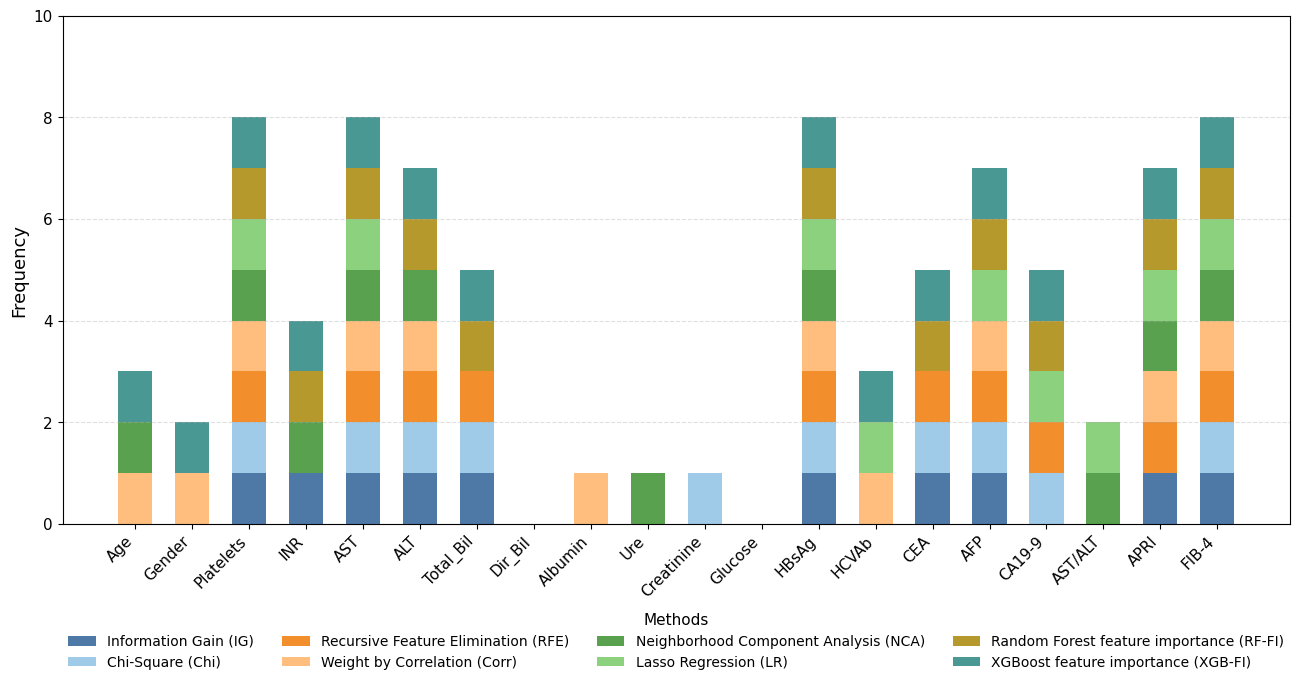

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Phương pháp
methods = ['Information Gain (IG)', 'Chi-Square (Chi)', 'Recursive Feature Elimination (RFE)', 'Weight by Correlation (Corr)', 'Neighborhood Component Analysis (NCA)', 'Lasso Regression (LR)', 'Random Forest feature importance (RF-FI)', 'XGBoost feature importance (XGB-FI)']

# Đặc trưng
features = ['Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT', 'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose', 'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4']

# Đặc trưng được chọn bởi từng phương pháp
method_features = {
    'Information Gain (IG)': ['AFP', 'HBsAg', 'APRI', 'AST', 'CEA', 'FIB-4', 'ALT', 'Platelets', 'Total_Bil', 'INR'],
    'Weight by Correlation (Corr)': ['HBsAg', 'Platelets', 'FIB-4', 'Gender', 'APRI', 'HCVAb', 'AST', 'AFP', 'Age', 'Albumin', 'ALT'],
    'Recursive Feature Elimination (RFE)': ['Platelets', 'AST', 'ALT', 'Total_Bil', 'HBsAg', 'CEA', 'AFP', 'CA19-9', 'APRI', 'FIB-4'],
    'Random Forest feature importance (RF-FI)': ['AFP', 'INR', 'Platelets', 'APRI', 'AST', 'HBsAg', 'Total_Bil', 'ALT', 'CEA', 'FIB-4', 'CA19-9'],
    'Neighborhood Component Analysis (NCA)': ['HBsAg', 'Platelets', 'INR', 'AST', 'ALT', 'Age', 'APRI', 'Ure', 'AST/ALT', 'FIB-4'],
    'Lasso Regression (LR)': ['AFP', 'FIB-4', 'APRI', 'HBsAg', 'CA19-9', 'AST', 'AST/ALT', 'HCVAb', 'Platelets'],
    'XGBoost feature importance (XGB-FI)': ['HBsAg', 'APRI', 'AFP', 'Gender', 'CEA', 'HCVAb', 'FIB-4', 'Age', 'CA19-9', 'ALT', 'AST', 'INR', 'Platelets', 'Total_Bil'],
    'Chi-Square (Chi)': ['AFP', 'CA19-9', 'CEA', 'Platelets', 'Creatinine', 'AST', 'ALT', 'FIB-4', 'HBsAg', 'Total_Bil']
}

# Ma trận dữ liệu
data = np.zeros((len(features), len(methods)))
for j, m in enumerate(methods):
    for f in method_features[m]:
        if f in features:
            i = features.index(f)
            data[i, j] += 1

x = np.arange(len(features))
bottom = np.zeros(len(features))

colors = [
    '#4E79A7', '#A0CBE8', '#F28E2B', '#FFBE7D',
    '#59A14F', '#8CD17D', '#B6992D', '#499894'
]

# Vẽ stacked bar chart (với cột mảnh hơn)
plt.figure(figsize=(14, 7))
bar_width = 0.6  # 🔹 giảm độ rộng cột
for j, m in enumerate(methods):
    plt.bar(x, data[:, j], bottom=bottom, label=m, color=colors[j], width=bar_width)
    bottom += data[:, j]

# Hiển thị
plt.xticks(x, features, rotation=45, ha='right', fontsize=11, fontstyle='normal')  # 🔹 chữ đứng
plt.yticks(fontsize=11)
plt.ylabel('Frequency', fontsize=13)

plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Legend bên dưới
plt.legend(
    title='Methods',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=10,
    title_fontsize=11,
    frameon=False
)

plt.tight_layout()
plt.show()